# 12 — `DifferentiableBandPassFilter`: bands as learnable hyperparameters

Wraps the static `BandPassFilter` so the centre frequencies
(`pha_mids`, `amp_mids`) carry gradients. Forward is identical;
backward updates the band locations.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

import scitex_nn

fs, seq_len = 500, 1024
pha_n, amp_n = 6, 8

filt = scitex_nn.DifferentiableBandPassFilter(
    sig_len=seq_len,
    fs=fs,
    pha_low_hz=2,
    pha_high_hz=20,
    pha_n_bands=pha_n,
    amp_low_hz=30,
    amp_high_hz=120,
    amp_n_bands=amp_n,
)

## Forward + backward sanity check

In [2]:
x = torch.randn(1, 1, seq_len, requires_grad=True)
y = filt(x)
print("output shape:", tuple(y.shape))
y.pow(2).mean().backward()
assert x.grad is not None and x.grad.abs().sum() > 0
print(f"input grad norm: {x.grad.norm().item():.4f}")
print(f"pha_mids learnable: {filt.pha_mids.requires_grad}")

output shape: (1, 1, 14, 1024)
input grad norm: 0.0087
pha_mids learnable: True


## Frequency response of every band

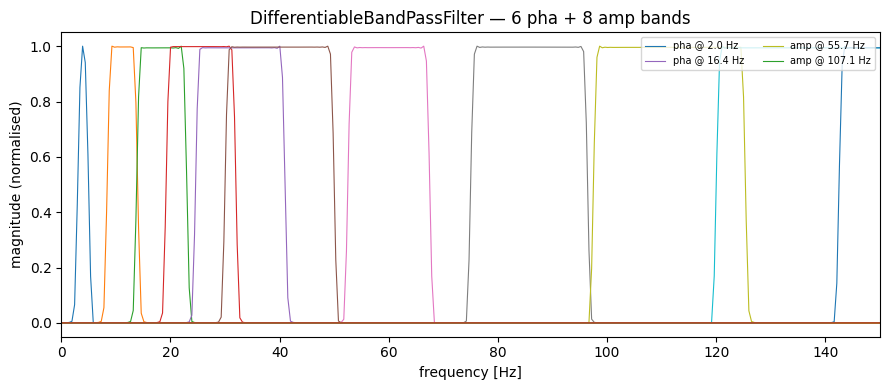

In [3]:
impulse = torch.zeros(1, 1, seq_len)
impulse[0, 0, seq_len // 2] = 1.0
with torch.no_grad():
    ir = filt(impulse).squeeze().numpy()
freqs = np.fft.rfftfreq(seq_len, d=1.0 / fs)
mag = np.abs(np.fft.rfft(ir, axis=-1))
mag /= mag.max(axis=-1, keepdims=True) + 1e-12

centres = np.concatenate(
    [filt.pha_mids.detach().numpy(), filt.amp_mids.detach().numpy()]
)

fig, ax = plt.subplots(figsize=(9, 4))
for k, c in enumerate(centres):
    kind = "pha" if k < pha_n else "amp"
    label = f"{kind} @ {c:.1f} Hz" if k % 4 == 0 else None
    ax.plot(freqs, mag[k], lw=0.8, label=label)
ax.set_xlim(0, 150)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", ncol=2, fontsize=7)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("magnitude (normalised)")
ax.set_title(f"DifferentiableBandPassFilter — {pha_n} pha + {amp_n} amp bands")
fig.tight_layout()
plt.show()